# Where Ontology Similarity and Text-Embedding Similarity Disagree

For a sample of term pairs in each of several ontologies, we compare:

- **ontology similarity**, computed from the terms' ancestor closures in three ways:
  1. Jaccard over `is_a` ancestors;
  2. Jaccard over `is_a` + `part_of` ancestors;
  3. **IC-weighted** Jaccard over `is_a` + `part_of` ancestors (simGIC), in which each
     shared ancestor counts in proportion to its information content, so sharing a
     generic ancestor counts for little;
- **text similarity**: cosine similarity of the terms' LLM embeddings, as served by OLS.

Most pairs fall along a common trend. The interesting cases are in the **corners**,
where ontology and text disagree:

- **ontology-similar, text-dissimilar**: terms that are close in the hierarchy but
  described in different words;
- **text-similar, ontology-dissimilar**: terms that read alike but are classified far
  apart.

All three ontology measures are available through OAK's `EmbeddingProviderInterface`:
the `closure` and `closure_ic` models produce the vectors, with
`closure_embedding_predicates` controlling which relations are followed, and the
`jaccard` / `weighted_jaccard` metrics compare them.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="eutils")
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import seaborn as sns

# reference palette (categorical slots in fixed order; sequential blue ramp)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})
SEQUENTIAL = sns.blend_palette(["#f0efec", "#86b6ef", "#2a78d6", "#0d366b"], as_cmap=True)

In [2]:
import random

import numpy as np
import pandas as pd

from oaklib import get_adapter
from oaklib.datamodels.vocabulary import IS_A, OWL_CLASS, PART_OF

MODEL = "text-embedding-3-large_pca512"
# ontology -> (id prefix, root to sample within; None for the whole ontology)
ONTOLOGIES = {
    "hp": ("HP", "HP:0000118"),  # Phenotypic abnormality
    "mondo": ("MONDO", None),
    "go": ("GO", None),
    "cl": ("CL", None),
}
N_RELATED, N_RANDOM, N_SHOW = 300, 100, 20
MEASURES = {
    "jaccard_isa": "Jaccard (is_a)",
    "jaccard_isa_partof": "Jaccard (is_a + part_of)",
    "simgic": "IC-weighted Jaccard (is_a + part_of)",
}
PRIMARY = "simgic"

## Sampling pairs

Purely random pairs are almost all unrelated, so they would pile up in one corner. To
cover the whole range of ontology similarity, most pairs are sampled by picking a term,
moving up to a random one of its `is_a` ancestors, then down to a random descendant of
that ancestor. A smaller number of fully random pairs is added. Only terms from the
ontology's own namespace are used (no imported terms), obsolete terms are excluded, and
for HP only terms under *Phenotypic abnormality* are used (no clinical modifiers,
inheritance modes, etc).

In [3]:
def sample_pairs(adapter, prefix, root=None, seed=0):
    rng = random.Random(seed)
    if root:
        candidates = adapter.descendants(root, predicates=[IS_A], reflexive=False)
    else:
        candidates = adapter.entities(filter_obsoletes=True, owl_type=OWL_CLASS)
    terms = sorted(t for t in candidates if t.startswith(prefix + ":"))
    term_set = set(terms)
    pairs = set()
    while len(pairs) < N_RELATED:
        a = rng.choice(terms)
        ancs = [x for x in adapter.ancestors(a, predicates=[IS_A], reflexive=False) if x in term_set]
        if not ancs:
            continue
        x = rng.choice(ancs)
        descs = [d for d in adapter.descendants(x, predicates=[IS_A], reflexive=False)
                 if d in term_set and d != a]
        if descs:
            pairs.add(tuple(sorted((a, rng.choice(descs)))))
    while len(pairs) < N_RELATED + N_RANDOM:
        a, b = rng.sample(terms, 2)
        pairs.add(tuple(sorted((a, b))))
    return sorted(pairs)

adapters, pair_sets = {}, {}
for name, (prefix, root) in ONTOLOGIES.items():
    adapters[name] = (get_adapter(f"sqlite:obo:{name}"), get_adapter(f"ols:{name}"))
    pair_sets[name] = sample_pairs(adapters[name][0], prefix, root)
    print(name, len(pair_sets[name]), "pairs")

hp 400 pairs


mondo 400 pairs


go 400 pairs


cl 400 pairs


## Scoring

For each ontology, closure vectors for all sampled terms are computed in one call so that
they share dimensions. Information content (IC) is computed from the ontology structure
(how many terms each ancestor subsumes), over the same `is_a` + `part_of` closure.
In the IC-weighted vectors, the shared position with the largest value is the **most
informative common ancestor** (MICA); it is listed in the tables to show where the
ontology places the pair.

The same vectors are available directly from the adapter:

```python
onto.closure_embedding_predicates = [IS_A, PART_OF]
ids, matrix = onto.entity_embeddings(terms, model="closure_ic")
onto.embedding_similarity_matrix(terms, model="closure_ic", metric="weighted_jaccard")
```

In [4]:
from oaklib.utilities.embeddings.closure_embeddings import closure_embeddings

PREDICATES = [IS_A, PART_OF]

def jaccard(x, y):
    x, y = x > 0, y > 0
    return (x & y).sum() / (x | y).sum()

def weighted_jaccard(x, y):
    return np.minimum(x, y).sum() / np.maximum(x, y).sum()

frames, micas = [], {}
for name, (onto, ols) in adapters.items():
    pairs = pair_sets[name]
    terms = sorted({t for p in pairs for t in p})
    ids1, _, C1 = closure_embeddings(onto, terms, predicates=[IS_A])
    ids2, vocab, C2 = closure_embeddings(onto, terms, predicates=PREDICATES)
    ic = dict(onto.information_content_scores(vocab, object_closure_predicates=PREDICATES))
    _, _, W = closure_embeddings(onto, ids2, predicates=PREDICATES, vocabulary=vocab, weights=ic)
    ix1, ix2 = {t: i for i, t in enumerate(ids1)}, {t: i for i, t in enumerate(ids2)}
    tids, T = ols.entity_embeddings(terms, model=MODEL)
    T = T / np.linalg.norm(T, axis=1, keepdims=True)
    tix = {t: i for i, t in enumerate(tids)}
    rows = []
    for a, b in pairs:
        if a not in tix or b not in tix:
            continue
        wa, wb = W[ix2[a]], W[ix2[b]]
        shared = np.minimum(wa, wb)
        micas[(a, b)] = vocab[int(shared.argmax())] if shared.max() > 0 else None
        rows.append({
            "ontology": name, "a": a, "b": b,
            "jaccard_isa": jaccard(C1[ix1[a]], C1[ix1[b]]),
            "jaccard_isa_partof": jaccard(C2[ix2[a]], C2[ix2[b]]),
            "simgic": weighted_jaccard(wa, wb),
            "text_sim": float(T[tix[a]] @ T[tix[b]]),
        })
    df = pd.DataFrame(rows)
    # disagreement: difference of within-ontology percentile ranks, per measure
    for m in MEASURES:
        df[f"disagreement_{m}"] = df[m].rank(pct=True) - df.text_sim.rank(pct=True)
    frames.append(df)
    print(f"{name}: {len(df)} pairs scored ({len(pairs) - len(df)} missing a text embedding)")
scores = pd.concat(frames, ignore_index=True)

hp: 400 pairs scored (0 missing a text embedding)


mondo: 400 pairs scored (0 missing a text embedding)


go: 400 pairs scored (0 missing a text embedding)


cl: 400 pairs scored (0 missing a text embedding)


## How well does each ontology measure agree with text?

Spearman correlation between each ontology measure and text similarity:

In [5]:
from scipy.stats import spearmanr

agreement = pd.DataFrame({
    label: scores.groupby("ontology", sort=False).apply(lambda d, m=m: spearmanr(d[m], d.text_sim).statistic)
    for m, label in MEASURES.items()
})
agreement.index = agreement.index.str.upper()
agreement.round(3)

,Jaccard (is_a),Jaccard (is_a + part_of),IC-weighted Jaccard (is_a + part_of)
ontology,,,
HP,0.748,0.748,0.789
MONDO,0.628,0.628,0.732
GO,0.706,0.725,0.760
CL,0.662,0.598,0.672


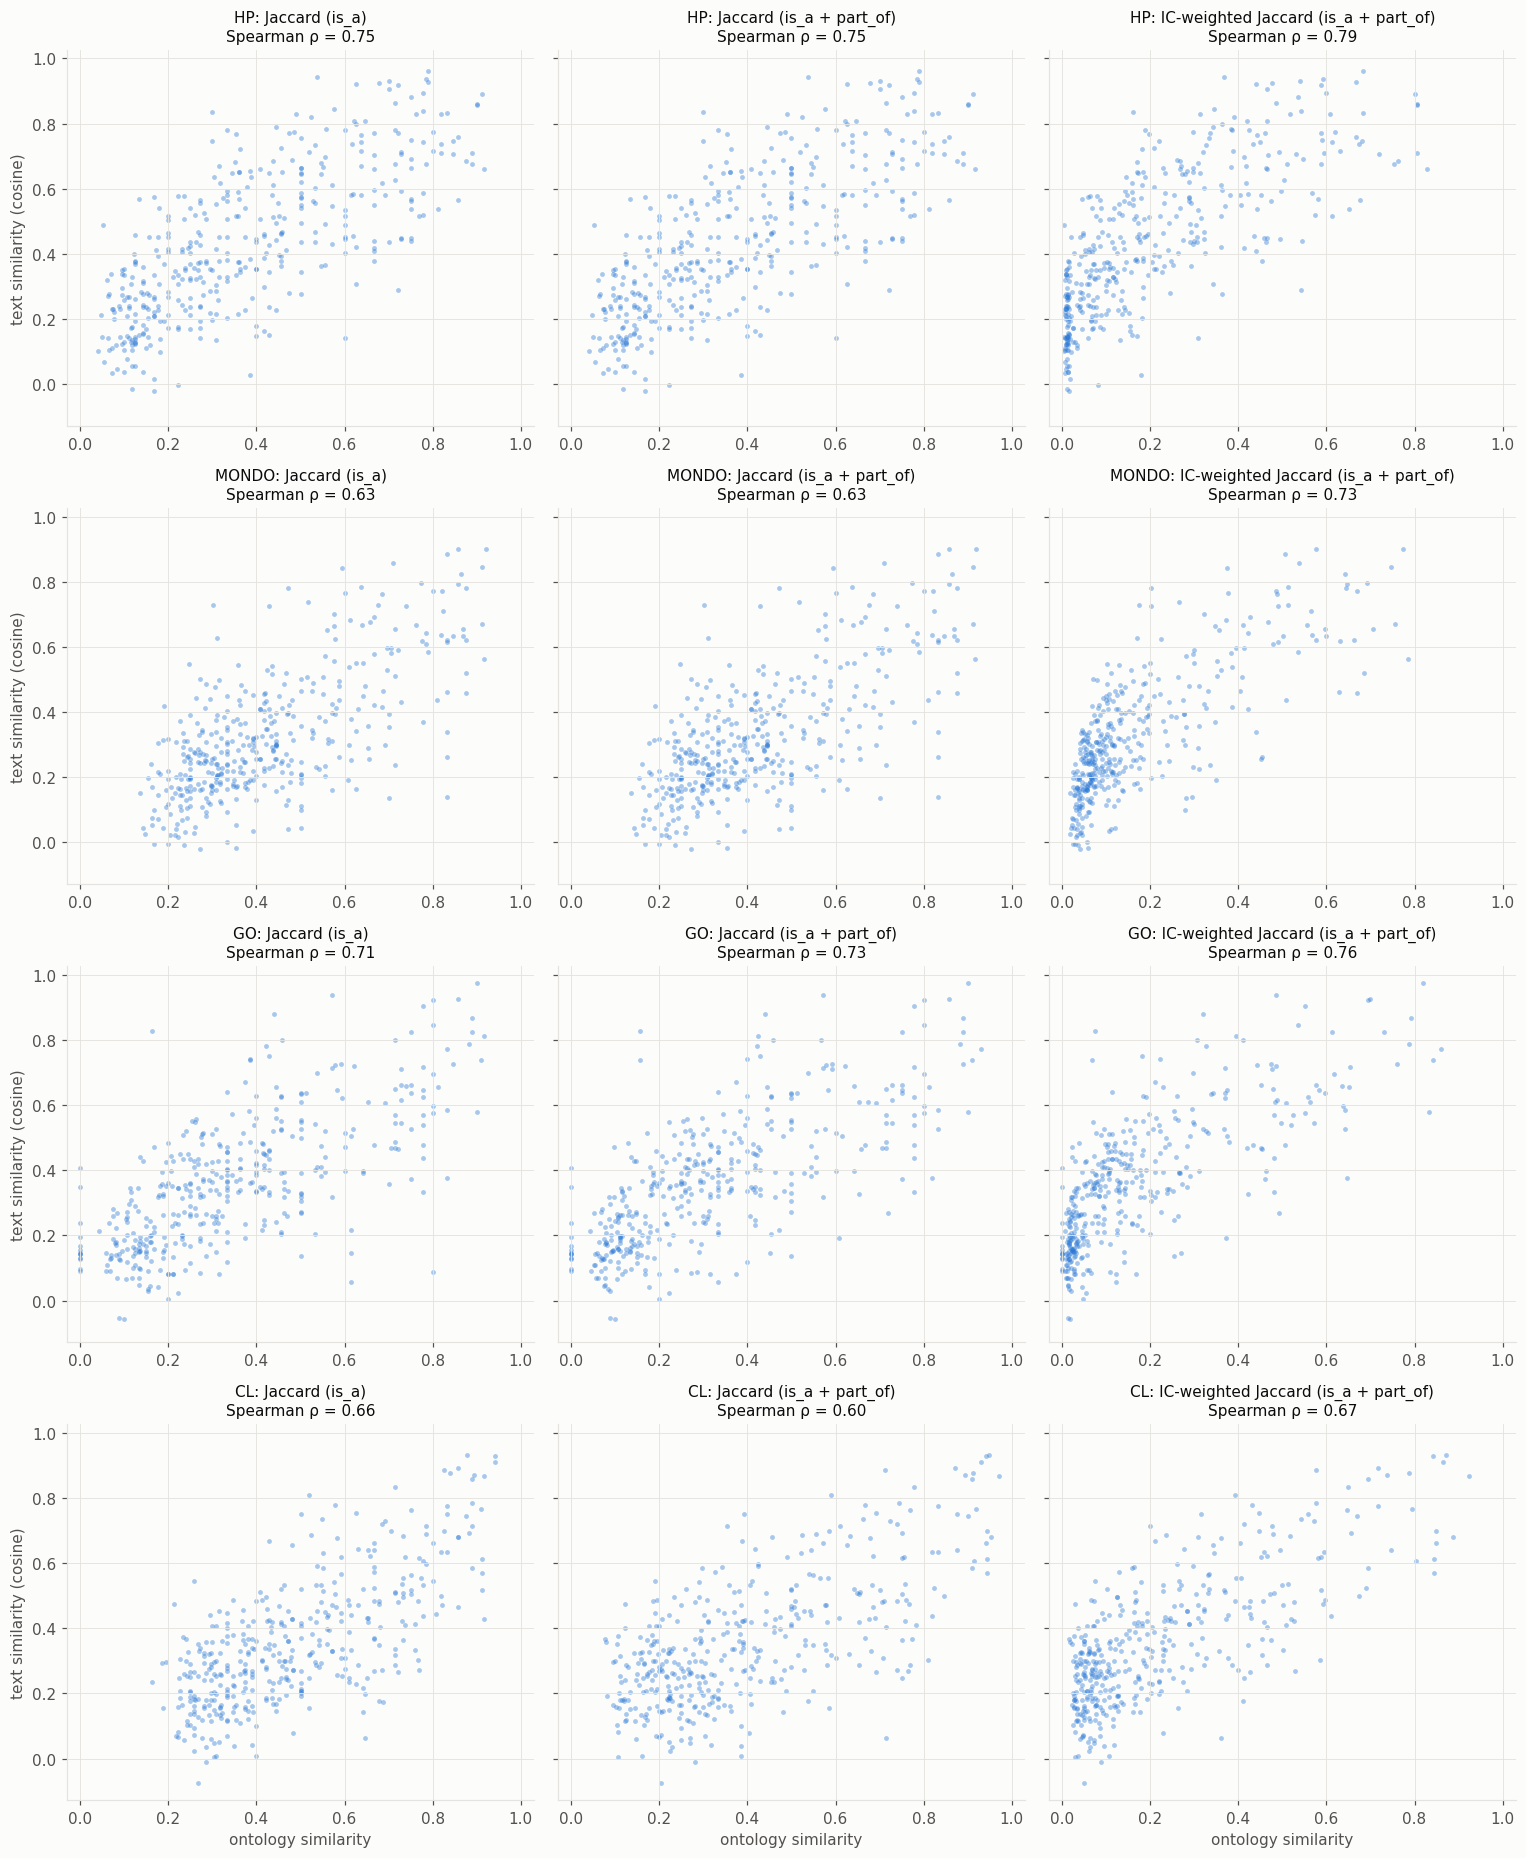

In [6]:
fig, axes = plt.subplots(len(ONTOLOGIES), len(MEASURES), figsize=(14, 17), sharey=True)
for row, (name, df) in zip(axes, scores.groupby("ontology", sort=False)):
    for ax, (m, label) in zip(row, MEASURES.items()):
        ax.scatter(df[m], df.text_sim, s=10, color=BLUE, alpha=0.4, linewidths=0)
        rho = spearmanr(df[m], df.text_sim).statistic
        ax.set_title(f"{name.upper()}: {label}\nSpearman ρ = {rho:.2f}", fontsize=10)
        ax.set_xlim(-0.03, 1.03)
for ax in axes[:, 0]:
    ax.set_ylabel("text similarity (cosine)")
for ax in axes[-1]:
    ax.set_xlabel("ontology similarity")
fig.tight_layout()

## The corners (IC-weighted Jaccard vs text)

The **disagreement** score is the difference between a pair's percentile rank under
ontology similarity and its percentile rank under text similarity. The 20 most extreme
pairs in each direction are highlighted and numbered; the tables below list them.

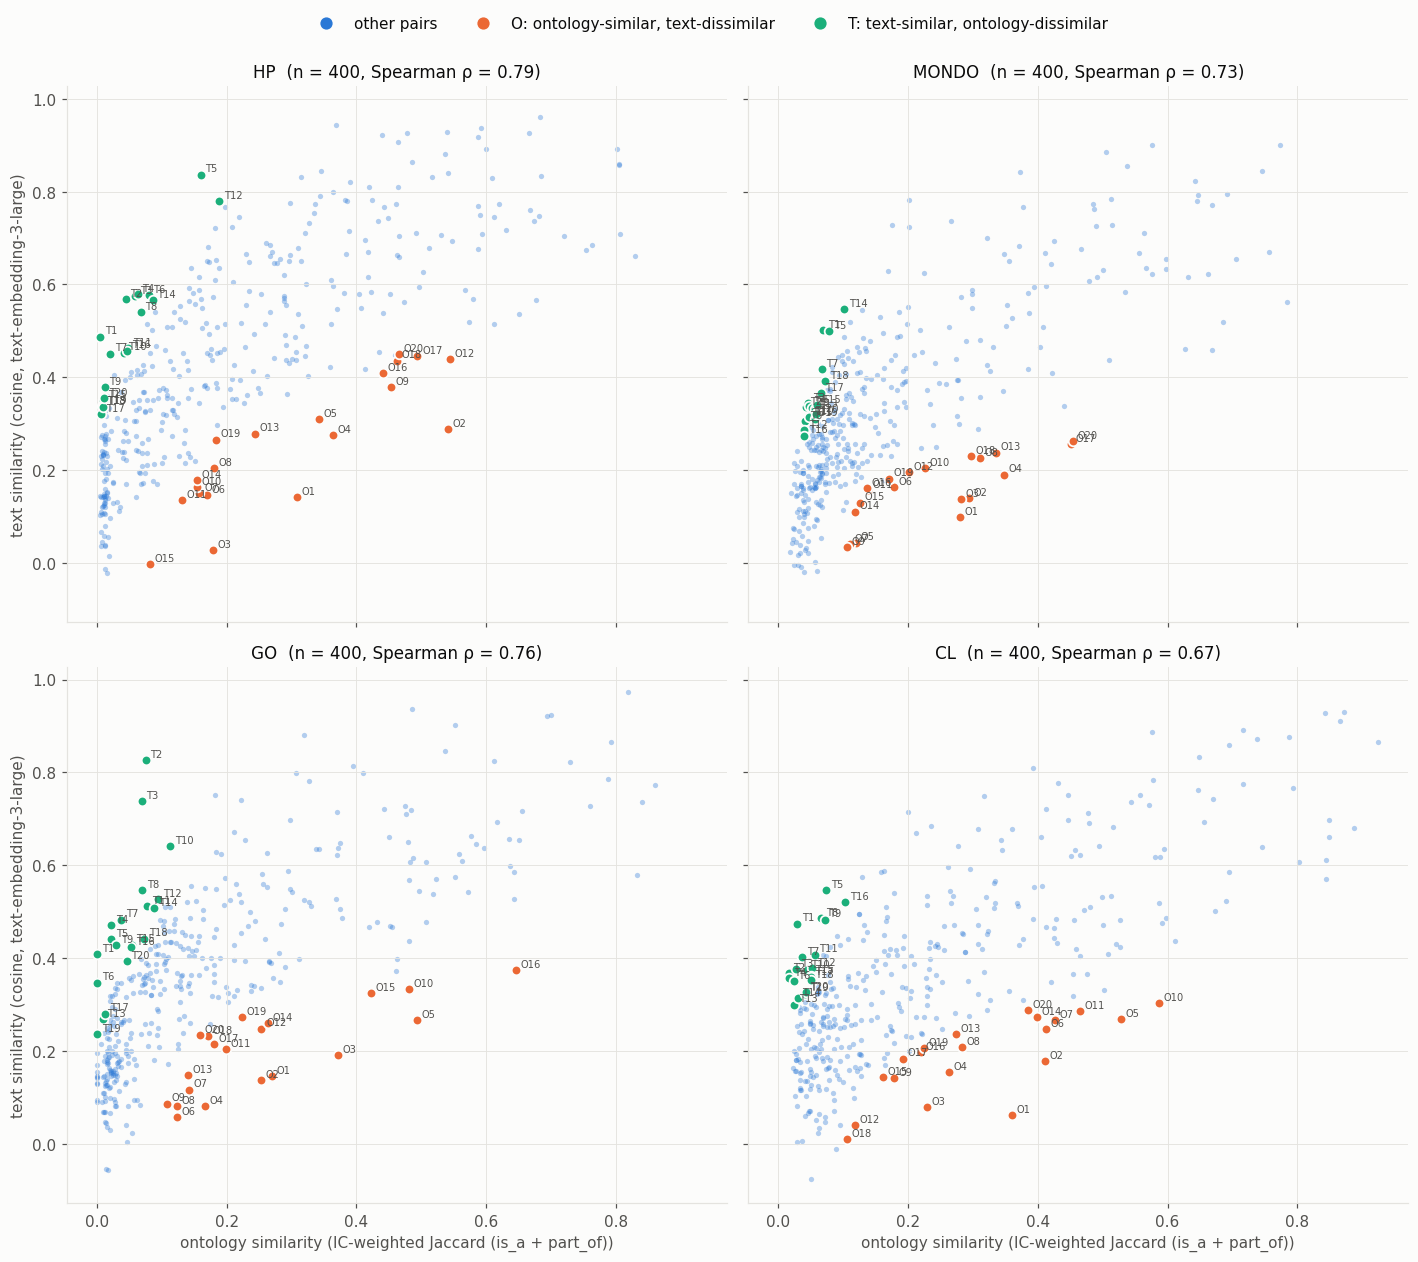

In [7]:
ONTO_ONLY, TEXT_ONLY = ORANGE, AQUA
d_col = f"disagreement_{PRIMARY}"
corners = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 11.5), sharex=True, sharey=True)
for ax, (name, df) in zip(axes.flat, scores.groupby("ontology", sort=False)):
    onto_only = df.nlargest(N_SHOW, d_col)
    text_only = df.nsmallest(N_SHOW, d_col)
    corners[name] = (onto_only, text_only)
    rest = df.drop(onto_only.index.union(text_only.index))
    ax.scatter(rest[PRIMARY], rest.text_sim, s=12, color=BLUE, alpha=0.35, linewidths=0)
    for sub, color, tag in ((onto_only, ONTO_ONLY, "O"), (text_only, TEXT_ONLY, "T")):
        ax.scatter(sub[PRIMARY], sub.text_sim, s=40, color=color, edgecolors=SURFACE, linewidths=1.2, zorder=3)
        for k, (_, r) in enumerate(sub.iterrows(), 1):
            ax.annotate(f"{tag}{k}", (r[PRIMARY], r.text_sim), xytext=(3, 2),
                        textcoords="offset points", fontsize=6.5, color=INK2)
    rho = spearmanr(df[PRIMARY], df.text_sim).statistic
    ax.set_title(f"{name.upper()}  (n = {len(df)}, Spearman ρ = {rho:.2f})")
for ax in axes[-1]:
    ax.set_xlabel(f"ontology similarity ({MEASURES[PRIMARY]})")
for ax in axes[:, 0]:
    ax.set_ylabel(f"text similarity (cosine, {MODEL.replace('_pca512', '')})")
handles = [plt.Line2D([], [], marker="o", linestyle="", color=c, markersize=7) for c in (BLUE, ONTO_ONLY, TEXT_ONLY)]
fig.legend(handles, ["other pairs", "O: ontology-similar, text-dissimilar", "T: text-similar, ontology-dissimilar"],
           loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.965))

How stable are the corners across ontology measures? For each ontology, the number of the
top-20 pairs in each corner that are also in the top 20 under the other measures:

In [8]:
rows = []
for name, df in scores.groupby("ontology", sort=False):
    for corner, pick in (("ontology-similar, text-dissimilar", "nlargest"), ("text-similar, ontology-dissimilar", "nsmallest")):
        top = {m: set(getattr(df, pick)(N_SHOW, f"disagreement_{m}").index) for m in MEASURES}
        rows.append({"ontology": name.upper(), "corner": corner,
                     **{f"shared with {MEASURES[m]}": len(top[PRIMARY] & top[m]) for m in MEASURES if m != PRIMARY}})
pd.DataFrame(rows).set_index(["ontology", "corner"])

shared with Jaccard (is_a)  \
ontology corner                                                          
HP       ontology-similar, text-dissimilar                          15   
         text-similar, ontology-dissimilar                          11   
MONDO    ontology-similar, text-dissimilar                          17   
         text-similar, ontology-dissimilar                          11   
GO       ontology-similar, text-dissimilar                          14   
         text-similar, ontology-dissimilar                          11   
CL       ontology-similar, text-dissimilar                          13   
         text-similar, ontology-dissimilar                           7   

                                            shared with Jaccard (is_a + part_of)  
ontology corner                                                                   
HP       ontology-similar, text-dissimilar                                    15  
         text-similar, ontology-dissimilar                                    11  
MONDO    ontology-similar, text-dissimilar                                    17  
         text-similar, ontology-dissimilar                                    11  
GO       ontology-similar, text-dissimilar                                    16  
         text-similar, ontology-dissimilar                                    14  
CL       ontology-similar, text-dissimilar                                    15  
         text-similar, ontology-dissimilar                                    14

## The corner pairs

For each ontology, the two tables list the 20 most extreme disagreements under the
IC-weighted measure, with all three ontology scores. "MICA" is the most informative
common ancestor over `is_a` + `part_of`.

In [9]:
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 55)
pd.set_option("display.max_rows", 50)

def corner_table(onto, sub, tag):
    ids = set(sub.a) | set(sub.b) | {micas[(r.a, r.b)] for r in sub.itertuples()} - {None}
    labels = dict(onto.labels(ids))
    out = []
    for k, r in enumerate(sub.itertuples(), 1):
        mica = micas[(r.a, r.b)]
        out.append({
            "#": f"{tag}{k}",
            "term 1": f"{labels.get(r.a)} ({r.a})",
            "term 2": f"{labels.get(r.b)} ({r.b})",
            "text": round(r.text_sim, 2),
            "IC-Jaccard": round(r.simgic, 2),
            "Jaccard is_a+part_of": round(r.jaccard_isa_partof, 2),
            "Jaccard is_a": round(r.jaccard_isa, 2),
            "MICA": labels.get(mica, mica) if mica else "(none)",
        })
    return pd.DataFrame(out).set_index("#")

for name, (onto_only, text_only) in corners.items():
    onto = adapters[name][0]
    display(Markdown(f"### {name.upper()}: ontology-similar, text-dissimilar"))
    display(corner_table(onto, onto_only, "O"))
    display(Markdown(f"### {name.upper()}: text-similar, ontology-dissimilar"))
    display(corner_table(onto, text_only, "T"))

### HP: ontology-similar, text-dissimilar

,term 1,term 2,text,IC-Jaccard,Jaccard is_a+part_of,Jaccard is_a,MICA
#,,,,,,,
O1,Slough (HP:0020013),Trichilemmal cyst (HP:0025246),0.14,0.31,0.60,0.60,Localized skin lesion
O2,Light-chain paraproteinemia (HP:0031048),Increased anti-dust mite IgE antibody level (HP:041...,0.29,0.54,0.72,0.72,Abnormal circulating immunoglobulin concentration
O3,Fragmented elastic fibers in the dermis (HP:0025167),V-sign (HP:0025536),0.03,0.18,0.38,0.38,Abnormal skin morphology
O4,Abnormality of abdominal situs (HP:0011620),Isomerism (HP:0031853),0.28,0.36,0.50,0.50,Heterotaxy
O5,Abnormal saccadic eye movements (HP:0000570),Compensatory chin elevation (HP:0001477),0.31,0.34,0.62,0.62,Abnormality of eye movement
O6,Abnormality of vitamin metabolism (HP:0100508),Shortened O-fucosylated glycan on properdin (HP:041...,0.15,0.17,0.40,0.40,Abnormal metabolism
O7,Hip pain (HP:0030838),Fish odor (HP:0410020),0.15,0.16,0.43,0.43,Constitutional symptom
O8,Recurrent skin infections (HP:0001581),Autoimmune encephalitis (HP:5210423),0.20,0.18,0.33,0.33,Increased inflammatory response
O9,Partial development of the penile shaft (HP:0008708),Varicocele (HP:0012871),0.38,0.45,0.67,0.67,Abnormal male external genitalia morphology


### HP: text-similar, ontology-dissimilar

,term 1,term 2,text,IC-Jaccard,Jaccard is_a+part_of,Jaccard is_a,MICA
#,,,,,,,
T1,Osteoma cutis (HP:0025027),Patchy sclerosis of the proximal phalanx of the 3rd...,0.49,0.01,0.05,0.05,Phenotypic abnormality
T2,Synostosis involving the 5th metacarpal (HP:0009708),Proximal radioulnar joint dislocation (HP:6000890),0.57,0.04,0.13,0.13,Abnormality of the upper limb
T3,Bone-in-a-bone appearance of forearm (HP:0003955),Bullet-shaped middle phalanx of the 3rd finger (HP:...,0.58,0.06,0.17,0.17,Abnormality of the upper limb
T4,Psychotic episodes (HP:0000725),Focal aware emotional seizure with laughing (HP:003...,0.58,0.06,0.22,0.22,Abnormal nervous system physiology
T5,Periorbital fullness (HP:0000629),Lower eyelid edema (HP:0012568),0.84,0.16,0.30,0.30,Abnormality of the periorbital region
T6,Hypoplasia of the ovary (HP:0008724),Increased antral follicle count (HP:0033086),0.58,0.08,0.24,0.24,Abnormality of the genital system
T7,Abnormality of liposaccharide metabolism (HP:0010968),Abnormality of abdominal situs (HP:0011620),0.45,0.02,0.20,0.20,Phenotypic abnormality
T8,Abnormality of the joint spaces of the elbow (HP:00...,Irregular epiphysis of the proximal phalanx of the ...,0.54,0.07,0.18,0.18,Abnormality of the upper limb
T9,Fatigable weakness of bulbar muscles (HP:0030192),Cervical motion tenderness (HP:6000107),0.38,0.01,0.12,0.12,Phenotypic abnormality


### MONDO: ontology-similar, text-dissimilar

...

,term 1,term 2,text,IC-Jaccard,Jaccard is_a+part_of,Jaccard is_a,MICA
#,,,,,,,
T1,integrin alpha9-beta1 complex (GO:0034679),negative regulation of fibronectin-dependent thymoc...,0.41,0.00,0.00,0.00,(none)
T2,negative regulation of dendritic spine development ...,positive regulation of dendritic spine morphogenesi...,0.83,0.07,0.16,0.16,regulation of dendritic spine development
T3,establishment or maintenance of cytoskeleton polari...,maintenance of neuroblast polarity (GO:0045201),0.74,0.07,0.16,0.38,establishment or maintenance of cell polarity
T4,UDP-N-acetylglucosamine transmembrane transporter a...,"2,3,4,5-tetrahydropyridine-2,6-dicarboxylate N-succ...",0.47,0.02,0.10,0.17,molecular_function
T5,protein localization to linear element (GO:0036181),positive regulation of protein localization to pres...,0.44,0.02,0.14,0.14,biological_process
T6,azurophil granule membrane (GO:0035577),negative regulation of lysosomal membrane permeabil...,0.35,0.00,0.00,0.00,(none)
T7,protein-N(PI)-phosphohistidine-trehalose phosphotra...,galactosamine-6-phosphate isomerase activity (GO:00...,0.48,0.04,0.13,0.20,catalytic activity
T8,inhibitory killer cell immunoglobulin-like receptor...,positive regulation of complement-dependent cytotox...,0.55,0.07,0.22,0.26,regulation of cellular process
T9,isocitrate-homoisocitrate dehydrogenase activity (G...,negative regulation of catalytic activity (GO:0043086),0.43,0.03,0.14,0.14,process


### CL: ontology-similar, text-dissimilar

,term 1,term 2,text,IC-Jaccard,Jaccard is_a+part_of,Jaccard is_a,MICA
#,,,,,,,
O1,olfactory ensheathing cell (CL:0011028),Astro-NT NN_1 Slc36a2 astrocyte (Mmus) (CL:4307029),0.06,0.36,0.71,0.65,glial cell
O2,melanophage (CL:0002060),CD8-alpha-positive plasmacytoid dendritic cell (CL:...,0.18,0.41,0.54,0.68,mononuclear phagocyte
O3,cone retinal bipolar cell (CL:0000752),hypothalamic gonadotropin-releasing hormone neuron ...,0.08,0.23,0.40,0.48,glutamatergic neuron
O4,superior cervical ganglion VIP neuron (CL:4033106),STRd D2 StrioMat Hybrid MSN indirect pathway medium...,0.15,0.26,0.59,0.52,neuron
O5,pvalb chandelier GABAergic interneuron (CL:4023036),GPe-NDB-SI LHX6-LHX8-GBX1 GABA GABAergic interneuro...,0.27,0.53,0.76,0.67,GABAergic interneuron
O6,M13 retinal ganglion cell (CL:0003046),untufted pyramidal neuron (CL:4023095),0.25,0.41,0.75,0.65,central nervous system neuron
O7,H2 horizontal cell (CL:0004218),spinal cord medial motor column neuron (CL:2000024),0.27,0.43,0.69,0.72,central nervous system neuron
O8,sacral ganglion TH neuron (CL:4033126),AMY-SLEA-BNST GABA GABAergic interneuron (Primate) ...,0.21,0.28,0.55,0.50,neuron
O9,totipotent stem cell (CL:0000052),airway submucosal gland duct basal cell (CL:4033024),0.14,0.18,0.29,0.64,somatic stem cell


### CL: text-similar, ontology-dissimilar

,term 1,term 2,text,IC-Jaccard,Jaccard is_a+part_of,Jaccard is_a,MICA
#,,,,,,,
T1,olfactory receptor cell (CL:0000207),extraglomerular mesangial cell (CL:0002173),0.47,0.03,0.12,0.21,eukaryotic cell
T2,malignant cell (CL:0001064),inner phalangeal cell (CL:0005015),0.37,0.02,0.08,0.24,cell
T3,epidermal mucus secreting cell (CL:0007019),hypendymal cell (CL:4023181),0.38,0.03,0.11,0.33,cell
T4,vagal neural crest cell (CL:0011017),tuft cell of nasal cavity respiratory epithelium (C...,0.36,0.02,0.08,0.29,cell
T5,somatotropin secreting cell (CL:0000295),hypothalamic gonadotropin-releasing hormone neuron ...,0.55,0.07,0.19,0.26,secretory cell
T6,seminiferous tubule epithelial cell (CL:0002625),somatic nurse-like cell (CL:4029003),0.35,0.02,0.10,0.38,cell
T7,epinephrine secreting cell (CL:0000454),intercalated cell of salivary gland (CL:4052048),0.40,0.04,0.12,0.33,secretory cell
T8,myoepithelial cell of trachea gland (CL:4033021),stomach smooth muscle circular layer cell (CL:4047036),0.49,0.07,0.20,0.35,contractile cell
T9,stratified cuboidal epithelial cell (CL:0000241),kidney proximal convoluted tubule epithelial cell (...,0.48,0.07,0.19,0.40,columnar/cuboidal epithelial cell


## What the corners show

**Choice of ontology measure.**

- IC weighting improves agreement with text in every ontology (Spearman ρ: HP 0.75 →
  0.79, MONDO 0.63 → 0.73, GO 0.71 → 0.76, CL 0.66 → 0.67). Sharing a generic ancestor
  no longer counts for much, which is also how the text models behave.
- Adding `part_of` changes nothing for HP and MONDO here (none of the sampled terms gets
  extra ancestors from it). It helps GO slightly (0.71 → 0.73), where cellular-component
  structure is mostly `part_of`. It hurts CL (0.66 → 0.60), where `part_of` reaches into
  anatomy and gives unrelated cells shared ancestors such as *tissue* and *epithelium*.
- The corners are fairly stable: 7 to 17 of the top-20 pairs in each corner are also in
  the top 20 under plain `is_a` Jaccard. The disagreements are mostly real differences
  between ontology and text, not artifacts of one measure. IC weighting lowers the
  scores of pairs that share only a broad ancestor, but some remain. For example, several
  MONDO pairs are still joined only by *hereditary disease* (O2, O6, O14), because many
  MONDO diseases are classified along broad axes only.

**HP (Phenotypic abnormality only).** The ontology-similar corner is now mostly
groupings by physiology or clinical context that the wording doesn't reveal:

- *Light-chain paraproteinemia* / *Increased anti-dust mite IgE antibody level*
  (abnormal circulating immunoglobulin concentration);
- *Recurrent skin infections* / *Autoimmune encephalitis* (increased inflammatory
  response);
- *Geophagia* / *Bulimia* (abnormal eating behavior);
- *Jaw claudication* / *Absent superficial temporal artery pulse* (abnormal arterial
  physiology; both are signs of giant cell arteritis).

A few groupings may be worth a curator's look, such as *Hip pain* and *Fish odor* both
sitting under *Constitutional symptom* (O7).

The text-similar corner includes pairs that look clinically related but share only a
broad ancestor. *Periorbital fullness* / *Lower eyelid edema* has a text similarity of
0.84 but meets only at *Abnormality of the periorbital region*, a candidate for a missing
link. Many of the other text-similar pairs are limb terms matched on bone vocabulary
(*phalanx*, *radioulnar*, *forearm*) but describing different kinds of abnormality.
Similarly, *Absent middle phalanx of 4th finger* / *Patchy sclerosis of the middle
phalanx of the 4th finger* (0.78) share an anatomical site; text weighs that heavily,
the ontology weighs the kind of abnormality too.

**GO.**

- Text failures: opposite polarity (*negative regulation of dendritic spine
  development* / *positive regulation of dendritic spine morphogenesis*, 0.83); shared
  chemical words across different activity classes (*alcohol O-cinnamoyltransferase* /
  *allyl-alcohol dehydrogenase*, 0.64, a transferase vs an oxidoreductase); and the
  shared phrasing of regulation terms.
- Ontology-only knowledge: *late endosome* / *fusiform vesicle* (both cytoplasmic
  vesicles; IC-weighted 0.65, text 0.37), and pairs of oxidoreductases.
- Protein complexes still populate the ontology-similar corner (e.g. *RecFOR complex* /
  *Hpa2 acetyltransferase complex*, joined via `part_of` *chromosome*). Their names say
  little about what they share.

**CL.** The ontology-similar corner is dominated by neurons and glia, many with
taxonomy-style labels (*Astro-NT NN_1 Slc36a2 astrocyte (Mmus)*, *STRd D2 StrioMat
Hybrid MSN …*, *GPe-NDB-SI LHX6-LHX8-GBX1 GABA …*). These are hard to find or match by
text and may benefit from more descriptive synonyms. The text-similar corner is mostly
shared vocabulary (*secreting*, *epithelial*, *endothelial*) across cells whose closest
common ancestor is just *cell*.

**Caveats.** The disagreement score is rank-based, so every ontology has a top 20 in each
corner even where the disagreement is mild. In MONDO, for example, many text-similar
picks have text similarity of only about 0.3. Read the tables together with the scores.
IC here is computed from ontology structure, not annotation frequency. Vectors are cached,
so changing `MODEL`, `MEASURES` or the sample sizes only fetches new terms.